In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import collections
import os
import re
import keras.backend as K
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: l

In [4]:
df=pd.read_csv("/kaggle/input/language-translation-englishfrench/eng_-french.csv")
df["French words/sentences"]=("<SOS> "+df["French words/sentences"]+" <EOS>")
df["English words/sentences"]=("<SOS> "+df["English words/sentences"]+" <EOS>")
df=df.sample(frac=1).reset_index(drop=True)
df

,English words/sentences,French words/sentences
0,<SOS> Tom looks like a friendly guy. <EOS>,<SOS> Tom a l'air d'un gars sympathique. <EOS>
1,<SOS> How long does it take on foot? <EOS>,<SOS> Combien de temps cela prend-il à pied ? ...
2,<SOS> We walked to the river. <EOS>,<SOS> Nous avons marché jusqu'à la rivière. <EOS>
3,<SOS> His car soon went out of sight. <EOS>,<SOS> Sa voiture devint vite hors de vue. <EOS>
4,<SOS> A father provides for his family. <EOS>,<SOS> Un père pourvoit à sa famille. <EOS>
...,...,...
175616,<SOS> I don't know all the details myself. <EOS>,<SOS> Je ne connais pas moi-même tous les déta...
175617,<SOS> I can't help how I look. <EOS>,<SOS> Je ne suis pas responsable de mon appare...
175618,<SOS> He sold us out. <EOS>,<SOS> Il nous a vendues. <EOS>
175619,<SOS> You're very tall. <EOS>,<SOS> Vous êtes très grands. <EOS>


In [5]:
df["French word numbers"]=(df['English words/sentences'].str.split().apply(len))
df["English word numbers"]=(df['French words/sentences'].str.split().apply(len))

<Axes: >

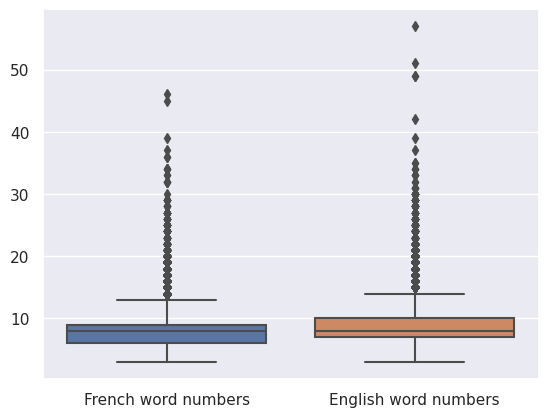

In [6]:
data_to_plot = df[["French word numbers", "English word numbers"]]
sns.boxplot(data=data_to_plot)

(0.0, 40.0)

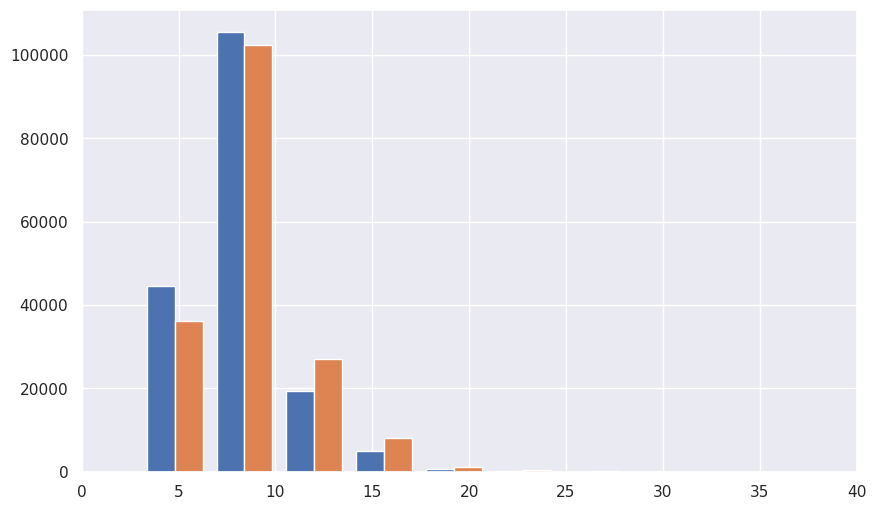

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(data_to_plot, bins=15, alpha=1)
plt.xlim(0, 40)

In [8]:
eng = df['English words/sentences']
fr = df['French words/sentences']

In [9]:
english_words_counter = collections.Counter([word for sentence in eng for word in sentence.split()])
french_words_counter = collections.Counter([word for sentence in fr for word in sentence.split()])

print('{} English words.'.format(len([word for sentence in eng for word in sentence.split()])))
print('{} unique English words.'.format(len(english_words_counter)))
print('10 Most common words in the English dataset:')
print('"' + '" "'.join(list(zip(*english_words_counter.most_common(10)))[0]) + '"')
print()
print('{} French words.'.format(len([word for sentence in fr for word in sentence.split()])))
print('{} unique French words.'.format(len(french_words_counter)))
print('10 Most common words in the French dataset:')
print('"' + '" "'.join(list(zip(*french_words_counter.most_common(10)))[0]) + '"')

1433340 English words.
27395 unique English words.
10 Most common words in the English dataset:
"<SOS>" "<EOS>" "I" "to" "you" "the" "a" "is" "Tom" "of"

1529074 French words.
44920 unique French words.
10 Most common words in the French dataset:
"<SOS>" "<EOS>" "de" "Je" "?" "pas" "que" "à" "ne" "la"


In [10]:
def tokenize(x):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(x)
    return tokenizer.texts_to_sequences(x), tokenizer

In [11]:
def pad(x, length=14):
    if length is None:
        length = max([len(sentence) for sentence in x])
    return pad_sequences(x, maxlen = length, padding = 'post')

In [12]:
def clean_text(text):
    cleaned_texts=[]
    for sent in text:
        cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', '', sent)
        cleaned_texts.append(cleaned_text)
    return cleaned_texts

In [13]:
def preprocess(x, y):


    preprocess_x, x_tk = tokenize(x)
    preprocess_y, y_tk = tokenize(y)

    preprocess_x = pad(preprocess_x)
    preprocess_y = pad(preprocess_y)

    return preprocess_x, preprocess_y, x_tk, y_tk

In [14]:
preproc_english_sentences, preproc_french_sentences, english_tokenizer, french_tokenizer = preprocess(eng, fr)

In [15]:
max_english_sequence_length = preproc_english_sentences.shape[1]
max_french_sequence_length = preproc_french_sentences.shape[1]
english_vocab_size = len(english_tokenizer.word_index)
french_vocab_size = len(french_tokenizer.word_index)

print("Max English sentence length:", max_english_sequence_length)
print("Max French sentence length:", max_french_sequence_length)
print("English vocabulary size:", english_vocab_size)
print("French vocabulary size:", french_vocab_size)

Max English sentence length: 14
Max French sentence length: 14
English vocabulary size: 14533
French vocabulary size: 30662


In [16]:
class positional_encoding(tf.keras.layers.Layer):
    def __init__(self,max_sentence_len,embedding_size,**kwargs):
        super().__init__(**kwargs)
        
        self.pos=np.arange(max_sentence_len).reshape(1,-1).T
        self.i=np.arange(embedding_size/2).reshape(1,-1)
        self.pos_emb=np.empty((1,max_sentence_len,embedding_size))
        self.pos_emb[:,:,0 : :2]=np.sin(self.pos / np.power(10000, (2 * self.i / embedding_size)))
        self.pos_emb[:,:,1 : :2]=np.cos(self.pos / np.power(10000, (2 * self.i / embedding_size)))
        self.positional_embedding = tf.cast(self.pos_emb,dtype=tf.float32)
        
    def call(self, inputs):
        return inputs + self.positional_embedding

In [17]:
class paddding_mask(tf.keras.layers.Layer):
    def __init__(self,**kwargs):
        super().__init__(**kwargs)
    def call(self,inputs):
        mask=1-tf.cast(tf.math.equal(inputs,0),tf.float32)
        return mask[:, tf.newaxis, :] 

In [18]:
class create_look_ahead_mask(tf.keras.layers.Layer):
    def __init__(self,**kwargs):
        super().__init__(**kwargs)
    def call(self,sequence_length):
        mask = tf.linalg.band_part(tf.ones((1, sequence_length, sequence_length)), -1, 0)
        return mask 

In [19]:
class input_layer_encoder(tf.keras.layers.Layer):
    def __init__(self,max_sentence_len,embedding_size,vocab_size,**kwargs):
        super().__init__(**kwargs)
        self.paddding_mask=paddding_mask()
        
        self.embedding=tf.keras.layers.Embedding(vocab_size,
                                                 embedding_size,
                                                 input_length=max_sentence_len,
                                                 input_shape=(max_sentence_len,))
        
        self.positional_encoding=positional_encoding(max_sentence_len,embedding_size)
    def call(self,inputs):
        mask=self.paddding_mask(inputs)
        
        emb=self.embedding(inputs)
        
        emb=self.positional_encoding(emb)
        return emb,mask

In [20]:
class input_layer_decoder(tf.keras.layers.Layer):
    def __init__(self,max_sentence_len,embedding_size,vocab_size,**kwargs):
        super().__init__(**kwargs)
        self.paddding_mask=paddding_mask()
        
        self.embedding=tf.keras.layers.Embedding(vocab_size,
                                                 embedding_size,
                                                 input_length=max_sentence_len,
                                                 input_shape=(max_sentence_len,))
        
        self.positional_encoding=positional_encoding(max_sentence_len,embedding_size)
        
        self.look_ahead_mask=create_look_ahead_mask()
        self.max_sentence_len=max_sentence_len
    def call(self,inputs):
        mask=self.paddding_mask(inputs)
        
        emb=self.embedding(inputs)
        
        emb=self.positional_encoding(emb)
        
        look_head_mak=self.look_ahead_mask(self.max_sentence_len)
        look_head_mak=tf.bitwise.bitwise_and(tf.cast(look_head_mak,dtype=np.int8),tf.cast(mask,dtype=np.int8))
        return emb,look_head_mak

In [21]:
class Encoder_layer(tf.keras.layers.Layer):
    def __init__(self,
                 embedding_size,
                 heads_num,
                 dense_num,
                 dropout_rate=0.0,
                 **kwargs):
        
        super().__init__(**kwargs)
        
        
        self.multi_attention=tf.keras.layers.MultiHeadAttention(
                num_heads=heads_num,
                key_dim=embedding_size,
                dropout=dropout_rate,
            )
        
        self.Dropout=tf.keras.layers.Dropout(dropout_rate)
        
        self.ff=tf.keras.Sequential([
            tf.keras.layers.Dense(dense_num,activation="relu"),
            tf.keras.layers.Dense(dense_num,activation="relu"),
            tf.keras.layers.Dense(dense_num,activation="relu"),
            tf.keras.layers.Dense(embedding_size,activation="relu"),
            tf.keras.layers.Dropout(dropout_rate)
        ])
        
        self.add=tf.keras.layers.Add()
        
        self.norm1=tf.keras.layers.LayerNormalization()
        self.norm2=tf.keras.layers.LayerNormalization()
    def call(self,inputs,mask,training):
        
        mha=self.multi_attention(inputs,inputs,inputs,mask)
        
        norm=self.norm1(self.add([inputs,mha]))
        
        fc=self.ff(norm)
        
        A=self.Dropout(fc,training=training)
        
        output=self.norm2(self.add([A,norm]))
        
        return output

In [22]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self,
                 max_sentence_len,
                 embedding_size,
                 vocab_size,
                 heads_num,
                 dense_num,
                 num_of_encoders,
                 **kwargs):
        super().__init__(**kwargs)
        self.add=tf.keras.layers.Add()
        self.input_layer=input_layer_encoder(max_sentence_len,embedding_size,vocab_size)
        self.encoder_layer=[Encoder_layer(embedding_size,heads_num, dense_num) for i in range (num_of_encoders)]
        self.num_layers=num_of_encoders
    def call(self,inputs,training):
        emb,mask=self.input_layer(inputs)
        skip=emb
        for layer in self.encoder_layer:
            emb = layer(emb, mask,training)
            emb = self.add([skip,emb])
            skip = emb
        return emb,mask

In [23]:
class decoder_layer(tf.keras.layers.Layer):
    def __init__(self,
                 embedding_size,
                 heads_num,
                 dense_num,
                 dropout_rate=0.0,
                 **kwargs):
        
        super().__init__(**kwargs)
            
        self.masked_mha=tf.keras.layers.MultiHeadAttention(
                num_heads=heads_num,
                key_dim=embedding_size,
                dropout=dropout_rate,
            )
        
        
        self.multi_attention=tf.keras.layers.MultiHeadAttention(
                num_heads=heads_num,
                key_dim=embedding_size,
                dropout=dropout_rate,
            )
        
        self.ff=tf.keras.Sequential([
            tf.keras.layers.Dense(dense_num,activation="relu"),
            tf.keras.layers.Dense(dense_num,activation="relu"),
            tf.keras.layers.Dense(dense_num,activation="relu"),
            tf.keras.layers.Dense(embedding_size,activation="relu"),
            tf.keras.layers.Dropout(dropout_rate)
        ])
        
        self.Dropout=tf.keras.layers.Dropout(dropout_rate)
        self.add=tf.keras.layers.Add()
        
        self.norm1=tf.keras.layers.LayerNormalization()
        self.norm2=tf.keras.layers.LayerNormalization()
        self.norm3=tf.keras.layers.LayerNormalization()
        
    def call(self,inputs,encoder_output,enc_mask,look_head_mask,training):
        
        mha_out,atten_score=self.masked_mha(inputs,inputs,inputs,look_head_mask,return_attention_scores=True)
        
        Q1=self.norm1(self.add([inputs,mha_out]))
        
        mha_out2,atten_score2=self.multi_attention(Q1,encoder_output,encoder_output,enc_mask,return_attention_scores=True)
        
        Z=self.norm2(self.add([Q1,mha_out2]))
        
        fc =  self.ff(Z)
        
        A=self.Dropout(fc,training=training)
        
        output=self.norm3(self.add([A,Z]))
        return output

In [24]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self,
                 max_sentence_len,
                 embedding_size,
                 vocab_size,
                 heads_num,
                 dense_num,
                 num_of_decoders,
                 **kwargs):
        super().__init__(**kwargs)
        self.add=tf.keras.layers.Add()
        self.input_layer=input_layer_decoder(max_sentence_len,embedding_size,vocab_size)
        self.decoder_layer=[decoder_layer(embedding_size,heads_num, dense_num) for i in range (num_of_decoders)]
        self.num_layers=num_of_decoders
    def call(self,inputs,encoder_output,enc_mask,training):
        emb,look_head_mask=self.input_layer(inputs)
        skip=emb
        for layer in self.decoder_layer:
            emb = layer(emb,encoder_output,enc_mask,look_head_mask,training)
            emb = self.add([skip,emb])
            skip = emb
        return emb

In [25]:
class transformer(tf.keras.Model):
    def __init__(self,
                 max_sentence_len_1=None,
                 max_sentence_len_2=None,
                 embedding_size=None,
                 vocab_size1=None,
                 vocab_size2=None,
                 heads_num=None,
                 dense_num=None,
                 num_of_encoders_decoders=None):

        super(transformer,self).__init__()

        self.Encoder=Encoder(max_sentence_len_1,
                             embedding_size,
                             vocab_size1,
                             heads_num,
                             dense_num,
                             num_of_encoders_decoders)

        self.Decoder=Decoder(max_sentence_len_2,
                             embedding_size,
                             vocab_size2,
                             heads_num,
                             dense_num,
                             num_of_encoders_decoders,)

        self.Final_layer=tf.keras.layers.Dense(vocab_size2, activation='relu')

        self.softmax=tf.keras.layers.Softmax(axis=-1)
    def call(self, inputs):
        input_sentence,output_sentence=inputs
        enc_output,enc_mask=self.Encoder(input_sentence)

        dec_output=self.Decoder(output_sentence,enc_output,enc_mask)

        final_out=self.Final_layer(dec_output)

        softmax_out=self.softmax(final_out)
        return softmax_out

In [26]:
tran=transformer(max_sentence_len_1=14,
                     max_sentence_len_2=13,
                     embedding_size=300,
                     vocab_size1=french_vocab_size+1,
                     vocab_size2=english_vocab_size+1,
                     heads_num=5,
                     dense_num=512,
                     num_of_encoders_decoders=2)

In [27]:
tran((preproc_french_sentences[:1],preproc_english_sentences[:1,:-1]))
tran.summary()

Model: "transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder (Encoder)           multiple                  14477548  
                                                                 
 decoder (Decoder)           multiple                  13249648  
                                                                 
 dense_16 (Dense)            multiple                  4374734   
                                                                 
 softmax (Softmax)           multiple                  0         
                                                                 
Total params: 32,101,930
Trainable params: 32,101,930
Non-trainable params: 0
_________________________________________________________________


In [28]:
tran.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
             optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
             metrics=["accuracy"])

In [45]:
tran.fit((preproc_french_sentences,preproc_english_sentences[:,:-1]),
         preproc_english_sentences[:,1:,tf.newaxis],
         epochs=10,
         batch_size=1024)

Epoch 1/10
172/172 [==============================] - 87s 504ms/step - loss: 0.5999 - accuracy: 0.9195
Epoch 2/10
172/172 [==============================] - 87s 505ms/step - loss: 0.5949 - accuracy: 0.9206
Epoch 3/10
172/172 [==============================] - 87s 506ms/step - loss: 0.5923 - accuracy: 0.9212
Epoch 4/10
172/172 [==============================] - 87s 505ms/step - loss: 0.5891 - accuracy: 0.9217
Epoch 5/10
172/172 [==============================] - 87s 504ms/step - loss: 0.5874 - accuracy: 0.9220
Epoch 6/10
172/172 [==============================] - 87s 505ms/step - loss: 0.5815 - accuracy: 0.9234
Epoch 7/10
172/172 [==============================] - 87s 506ms/step - loss: 0.5765 - accuracy: 0.9248
Epoch 8/10
172/172 [==============================] - 87s 506ms/step - loss: 0.5704 - accuracy: 0.9264
Epoch 9/10
172/172 [==============================] - 87s 506ms/step - loss: 0.5714 - accuracy: 0.9259
Epoch 10/10
172/172 [==============================] - 87s 504ms/step - l

In [34]:
def prepare_pred(sent):
    output=english_tokenizer.texts_to_sequences(sent)
    output=pad(output,13)
    return output

In [35]:
def pred(i):
    sent=["<SOS>"]
    french_token=prepare_pred(sent)
    word=np.argmax(tran.predict((preproc_french_sentences[[i]],french_token),verbose=0),-1)[0,0]
    sent[0]=sent[0]+ " "+english_tokenizer.sequences_to_texts(np.array([[word]]))[0]
    for j in range(1,12):
        french_token=prepare_pred(sent)
        word=np.argmax(tran.predict((preproc_french_sentences[[i]],french_token),verbose=0),-1)[0,j]
        sent[0]=sent[0]+ " "+english_tokenizer.sequences_to_texts(np.array([[word]]))[0]
        if english_tokenizer.sequences_to_texts(np.array([[word]]))[0]=="eos":
            break
    return sent

In [36]:
import random

In [38]:
def show():
    i=random.randint(0,170111)
    print("french sent : ",french_tokenizer.sequences_to_texts(preproc_french_sentences[[i]]))
    print("predict sent : ",pred(i))
    print("true sent : ",english_tokenizer.sequences_to_texts(preproc_english_sentences[[i]]))

In [49]:
for i in range(10):
    show()
    print("----------------")

french sent :  ['sos je parle un peu anglais eos']
predict sent :  ['<SOS> i can speak a little english eos']
true sent :  ['sos i can speak a little english eos']
----------------
french sent :  ['sos tu as dit que tu avais une théorie eos']
predict sent :  ['<SOS> you said you had a theory eos']
true sent :  ['sos you said you had a theory eos']
----------------
french sent :  ["sos je n'aurais jamais pensé que j'aurais à entretenir une famille aussi grande eos"]
predict sent :  ['<SOS> i never thought i would have to go this far away eos']
true sent :  ['sos i never thought i would have to support such a large family eos']
----------------
french sent :  ['sos tom a perdu ses lunettes quelque part au jardin eos']
predict sent :  ['<SOS> tom lost his uncle has been living in the garden eos']
true sent :  ['sos tom lost his glasses somewhere in the garden eos']
----------------
french sent :  ['sos votre mariage est à mal eos']
predict sent :  ['<SOS> your wedding is wrong eos']
true 